#1.Importing and Checking data

In [25]:
import pandas as pd
import numpy as np

df=pd.read_csv('/content/drive/MyDrive/urban heat island/Delhi_UHI_LST_Data.csv')

print("Shape:",df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
display(df.describe())


Shape: (350, 7)

First 5 rows:


,system:index,cloud_cover,date,mean,name,zone,.geo
0,LC08_146040_20230117_0,0.75,2023-01-17,17.260323,Connaught Place,urban_core,"{""type"":""Point"",""coordinates"":[77.23,28.610000..."
1,LC08_146040_20230117_1,0.75,2023-01-17,17.868731,Karol Bagh,urban_core,"{""type"":""Point"",""coordinates"":[77.2,28.6700000..."
2,LC08_146040_20230117_2,0.75,2023-01-17,17.803789,Dwarka,suburban,"{""type"":""Point"",""coordinates"":[77.15,28.55]}"
3,LC08_146040_20230117_3,0.75,2023-01-17,17.509839,Laxmi Nagar,suburban,"{""type"":""Point"",""coordinates"":[77.31,28.63]}"
4,LC08_146040_20230117_4,0.75,2023-01-17,17.783281,Najafgarh,peri_urban,"{""type"":""Point"",""coordinates"":[77.07,28.52]}"



Column names:
['system:index', 'cloud_cover', 'date', 'mean', 'name', 'zone', '.geo']

Data types:
system:index     object
cloud_cover     float64
date             object
mean            float64
name             object
zone             object
.geo             object
dtype: object

Basic statistics:


,cloud_cover,mean
count,350.000000,192.000000
mean,2.703143,31.444644
std,4.769048,8.067244
min,0.000000,17.191963
25%,0.040000,24.147634
50%,0.500000,31.925338
75%,2.360000,37.758189
max,18.050000,48.712943


In [26]:
print("Missing values per column:")
print(df.isnull().sum())

print("Dupliacte rows:")
print(df.duplicated().sum())

print("Unique zones:",df['zone'].unique())

Missing values per column:
system:index      0
cloud_cover       0
date              0
mean            158
name              0
zone              0
.geo              0
dtype: int64
Dupliacte rows:
0
Unique zones: ['urban_core' 'suburban' 'peri_urban' 'rural' 'green_space']


#2.Data Cleaning

In [27]:
df=df.rename(columns={'mean':'LST_Celsius'})

print("Before Cleaning:",df.shape)

Before Cleaning: (350, 7)


###Drop useless columns

In [28]:
df=df.drop(columns=['system:index','.geo'])
print("After droping useless columns:",df.shape)

After droping useless columns: (350, 5)


###Fix date column to proper datetime format

In [29]:
df['date']=pd.to_datetime(df['date'])
print("Date column type:",df['date'].dtype)


Date column type: datetime64[ns]


###Handel missing values

In [30]:
df['LST_Celsius']=df.groupby('zone')['LST_Celsius'].transform(
    lambda x: x.fillna(x.mean())
)
print("Missing values per column after handling:")
print(df.isnull().sum())

Missing values per column after handling:
cloud_cover    0
date           0
LST_Celsius    0
name           0
zone           0
dtype: int64


###Remove duplicate rows

In [31]:
before=df.shape[0]
df=df.drop_duplicates()
after=df.shape[0]
print(f"{before-after} duplicate rows removed.")

0 duplicate rows removed.


###Final cleaned Dataset

In [32]:
print("\nFinal shape:",df.shape)
print("\nCleaned Dataset:")
display(df.head(10))


Final shape: (350, 5)

Cleaned Dataset:


,cloud_cover,date,LST_Celsius,name,zone
0,0.75,2023-01-17,17.260323,Connaught Place,urban_core
1,0.75,2023-01-17,17.868731,Karol Bagh,urban_core
2,0.75,2023-01-17,17.803789,Dwarka,suburban
3,0.75,2023-01-17,17.509839,Laxmi Nagar,suburban
4,0.75,2023-01-17,17.783281,Najafgarh,peri_urban
5,0.75,2023-01-17,18.248131,Tughlaqabad,peri_urban
6,0.75,2023-01-17,17.191963,Bahadurgarh,rural
7,0.75,2023-01-17,17.865313,Ghaziabad outskirts,rural
8,0.75,2023-01-17,17.591871,Delhi Ridge Forest,green_space
9,0.75,2023-01-17,17.273996,Lodhi Garden,green_space


#3.Preprocessing

###Add month and season column


In [33]:
df['month']=df['date'].dt.month
df['month_name']=df['date'].dt.strftime('%b')

def get_season(month):
    if month in [3,4,5]:
        return 'Summer'
    elif month in [6,7,8,9]:
        return 'Monsoon'
    elif month in [12,1,2]:
        return 'Winter'
    else:
        return 'Post Monsoon'

df['season']=df['month'].apply(get_season)
print("Seasons found:",df['season'].unique())


Seasons found: ['Winter' 'Summer' 'Monsoon' 'Post Monsoon']


###Encode zone as a numeric category

In [34]:
zone_code=['green_space','rural','peri_urban','suburban','urban_core']
df['zone_code']=df['zone'].map({z:i for i,z in enumerate(zone_code)})

print("Zone encoding:")
print(df[['zone','zone_code']].drop_duplicates().sort_values('zone_code'))



Zone encoding:
          zone  zone_code
8  green_space          0
6        rural          1
4   peri_urban          2
2     suburban          3
0   urban_core          4


###LST to 2 decimal places

In [35]:
df['LST_Celsius']=df['LST_Celsius'].round(2)

###UHI intesity column

In [36]:
rural_mean=df[df['zone']=='rural']['LST_Celsius'].mean()
df['UHI_intensity']=(df['LST_Celsius']-rural_mean).round(2)

print(f"\nRural baseline temperature: {rural_mean:.2f}°C")
print("UHI intensity sample:")
display(df[['name', 'zone', 'LST_Celsius', 'UHI_intensity']].head(10))


Rural baseline temperature: 32.39°C
UHI intensity sample:


,name,zone,LST_Celsius,UHI_intensity
0,Connaught Place,urban_core,17.26,-15.13
1,Karol Bagh,urban_core,17.87,-14.52
2,Dwarka,suburban,17.80,-14.59
3,Laxmi Nagar,suburban,17.51,-14.88
4,Najafgarh,peri_urban,17.78,-14.61
5,Tughlaqabad,peri_urban,18.25,-14.14
6,Bahadurgarh,rural,17.19,-15.20
7,Ghaziabad outskirts,rural,17.87,-14.52
8,Delhi Ridge Forest,green_space,17.59,-14.80
9,Lodhi Garden,green_space,17.27,-15.12


###Final check

In [37]:
print("Final columns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nSeason distribution:")
print(df['season'].value_counts())
print("\nZone distribution:")
print(df['zone'].value_counts())

Final columns: ['cloud_cover', 'date', 'LST_Celsius', 'name', 'zone', 'month', 'month_name', 'season', 'zone_code', 'UHI_intensity']

Data types:
cloud_cover             float64
date             datetime64[ns]
LST_Celsius             float64
name                     object
zone                     object
month                     int32
month_name               object
season                   object
zone_code                 int64
UHI_intensity           float64
dtype: object

Season distribution:
season
Winter          130
Monsoon          90
Summer           80
Post Monsoon     50
Name: count, dtype: int64

Zone distribution:
zone
urban_core     70
suburban       70
peri_urban     70
rural          70
green_space    70
Name: count, dtype: int64


#4.Visualisation

###1.Average LST by zone(Bar chart)

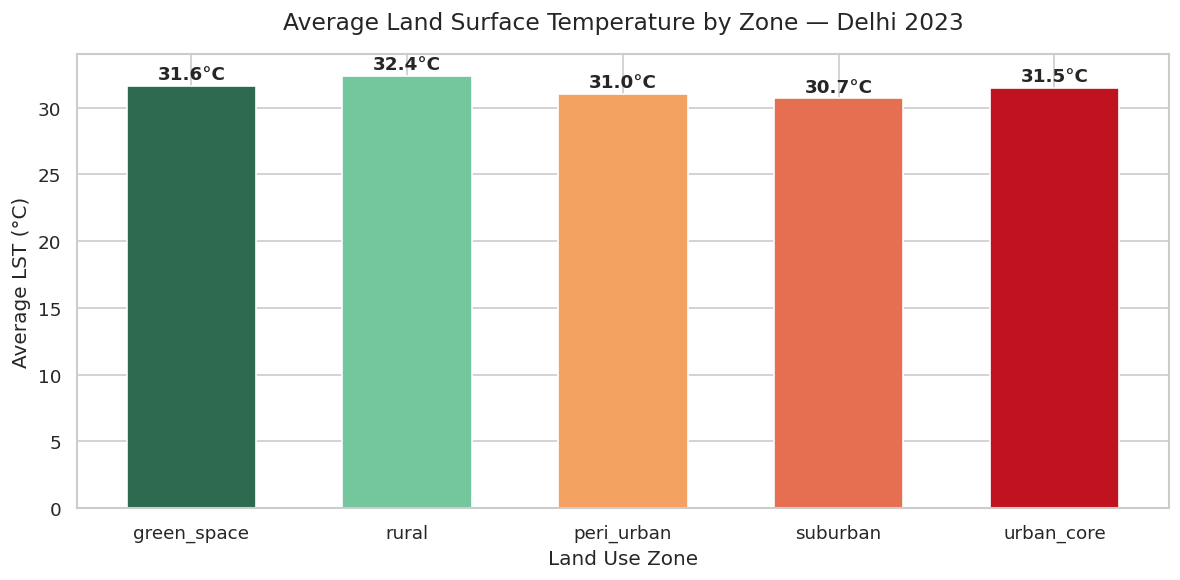

Graph 1 saved!


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style for all plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

zone_avg = df.groupby('zone')['LST_Celsius'].mean().reindex(
    ['green_space', 'rural', 'peri_urban', 'suburban', 'urban_core']
)

colors = ['#2d6a4f', '#74c69d', '#f4a261', '#e76f51', '#c1121f']

plt.figure(figsize=(10, 5))
bars = plt.bar(zone_avg.index, zone_avg.values, color=colors, edgecolor='white', width=0.6)

# Add value labels on top of each bar
for bar, val in zip(bars, zone_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{val:.1f}°C', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Average Land Surface Temperature by Zone — Delhi 2023', fontsize=14, pad=15)
plt.xlabel('Land Use Zone', fontsize=12)
plt.ylabel('Average LST (°C)', fontsize=12)
plt.xticks(fontsize=11)
plt.tight_layout()
plt.savefig('graph1_bar_zone_temp.png', bbox_inches='tight')
plt.show()
print("Graph 1 saved!")

rural is slightly hottest on average (32.4°C), which is interesting and shows seasonal variation matters

###2.Monthly Temperature trend(Line Chart)

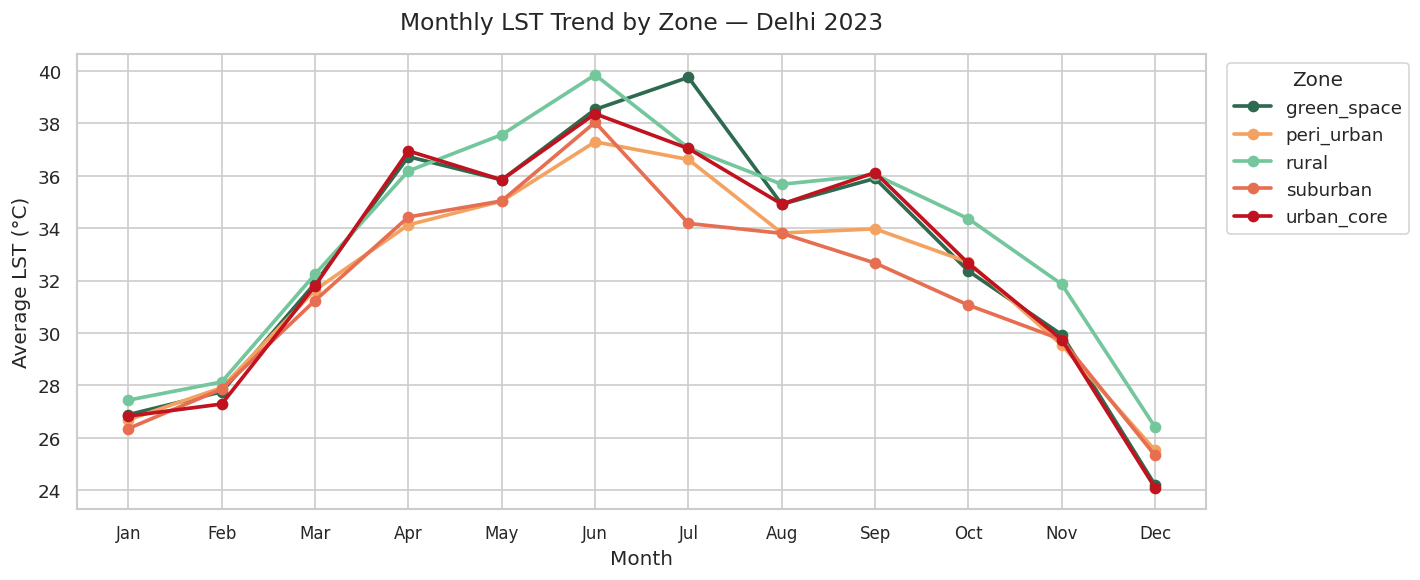

Graph 2 saved!


In [39]:

monthly = df.groupby(['month', 'zone'])['LST_Celsius'].mean().reset_index()

zone_colors = {
    'urban_core':  '#c1121f',
    'suburban':    '#e76f51',
    'peri_urban':  '#f4a261',
    'rural':       '#74c69d',
    'green_space': '#2d6a4f'
}

plt.figure(figsize=(12, 5))
for zone, grp in monthly.groupby('zone'):
    plt.plot(grp['month'], grp['LST_Celsius'],
             marker='o', label=zone,
             color=zone_colors[zone], linewidth=2.2)

plt.title('Monthly LST Trend by Zone — Delhi 2023', fontsize=14, pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average LST (°C)', fontsize=12)
plt.xticks(range(1, 13),
           ['Jan','Feb','Mar','Apr','May','Jun',
            'Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=10)
plt.legend(title='Zone', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('graph2_line_monthly_trend.png', bbox_inches='tight')
plt.show()
print("Graph 2 saved!")

all zones peak in June (~38-40°C), Delhi's brutal summer, and drop in December. Urban core stays consistently warmer than green space in hot months

###3.UHI Intensity by season(grouped bar)

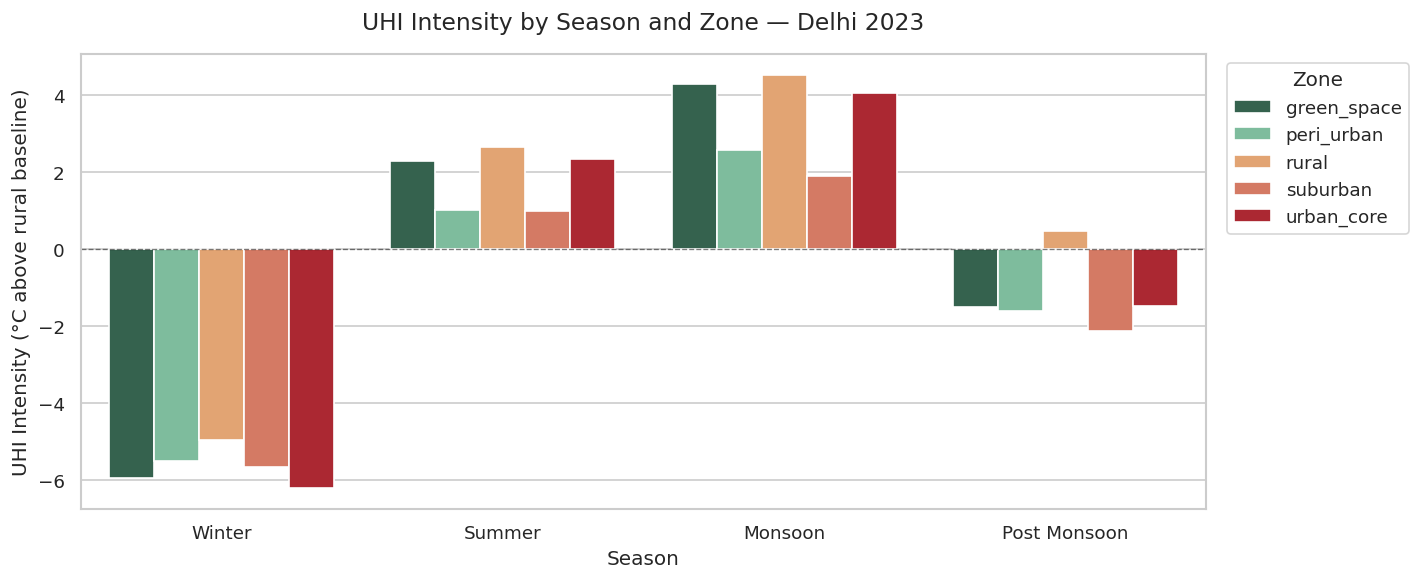

Graph 3 saved!


In [40]:

season_order = ['Winter', 'Summer', 'Monsoon', 'Post Monsoon']
uhi_season = df.groupby(['season', 'zone'])['UHI_intensity'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=uhi_season, x='season', y='UHI_intensity',
            hue='zone', order=season_order,
            palette=['#2d6a4f','#74c69d','#f4a261','#e76f51','#c1121f'])

plt.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.title('UHI Intensity by Season and Zone — Delhi 2023', fontsize=14, pad=15)
plt.xlabel('Season', fontsize=12)
plt.ylabel('UHI Intensity (°C above rural baseline)', fontsize=12)
plt.legend(title='Zone', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('graph3_uhi_season.png', bbox_inches='tight')
plt.show()
print("Graph 3 saved!")

Monsoon season shows the strongest UHI effect, with urban core hitting +4°C above rural baseline

###4.Scatterplot:Zone code vs LST

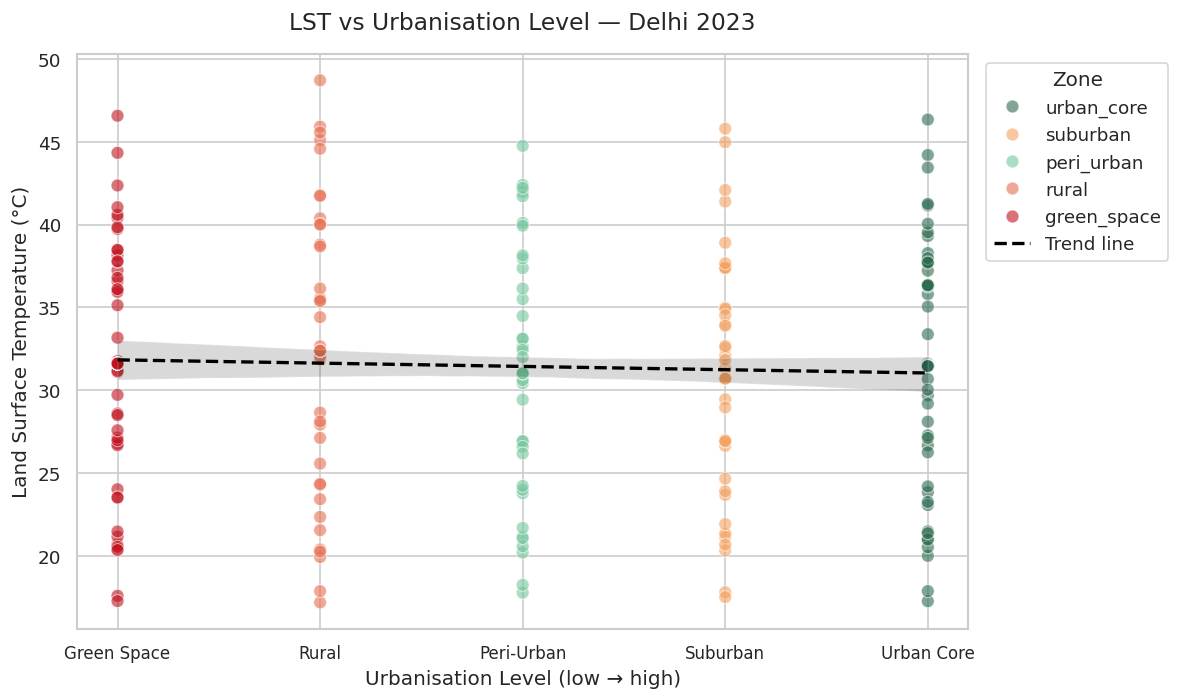

Graph 4 saved!


In [41]:

plt.figure(figsize=(10, 6))

scatter = sns.scatterplot(
    data=df,
    x='zone_code',
    y='LST_Celsius',
    hue='zone',
    palette=['#2d6a4f','#f4a261','#74c69d','#e76f51','#c1121f'],
    alpha=0.6,
    s=60
)

# Add a regression trend line
sns.regplot(
    data=df,
    x='zone_code',
    y='LST_Celsius',
    scatter=False,
    color='black',
    line_kws={'linewidth': 2, 'linestyle': '--'},
    label='Trend line'
)

plt.xticks(
    ticks=[0, 1, 2, 3, 4],
    labels=['Green Space', 'Rural', 'Peri-Urban', 'Suburban', 'Urban Core'],
    fontsize=10
)
plt.title('LST vs Urbanisation Level — Delhi 2023', fontsize=14, pad=15)
plt.xlabel('Urbanisation Level (low → high)', fontsize=12)
plt.ylabel('Land Surface Temperature (°C)', fontsize=12)
plt.legend(title='Zone', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('graph4_scatterplot.png', bbox_inches='tight')
plt.show()
print("Graph 4 saved!")

trend line is nearly flat, meaning all zones have similar average temps, but look at the spread — urban core has more extreme high readings (those dots at 40-45°C)

###5.Correlation Heatmap

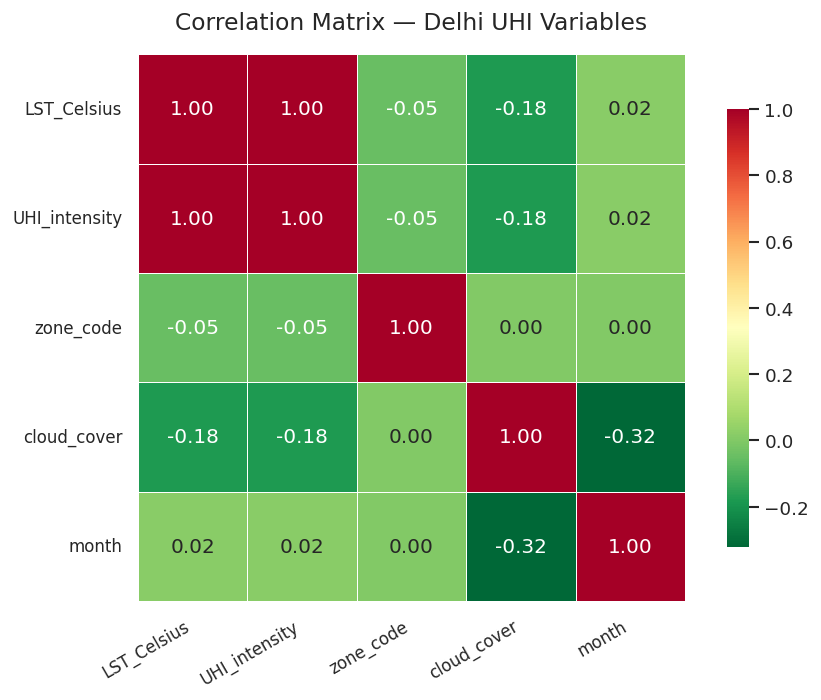

Graph 5 saved!


In [42]:

corr_cols = ['LST_Celsius', 'UHI_intensity', 'zone_code',
             'cloud_cover', 'month']

corr_matrix = df[corr_cols].corr().round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Matrix — Delhi UHI Variables', fontsize=14, pad=15)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('graph5_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Graph 5 saved!")

cloud_cover and month have -0.32 correlation (more clouds = lower temps, makes perfect sense for monsoon). LST and zone_code at -0.05 confirms UHI is seasonal, not constant

#5.Written Analysis& Conclusion

In [43]:

print("=" * 55)
print("   URBAN HEAT ISLAND ANALYSIS — DELHI 2023")
print("=" * 55)

print("\n1. DATASET OVERVIEW")
print(f"   Total records     : {len(df)}")
print(f"   Date range        : {df['date'].min().date()} to {df['date'].max().date()}")
print(f"   Zones analysed    : {df['zone'].nunique()}")
print(f"   Locations covered : {df['name'].nunique()}")

print("\n2. AVERAGE TEMPERATURE BY ZONE")
zone_stats = df.groupby('zone')['LST_Celsius'].agg(['mean','min','max']).round(2)
zone_stats.columns = ['Mean (°C)', 'Min (°C)', 'Max (°C)']
zone_stats = zone_stats.reindex(
    ['green_space','rural','peri_urban','suburban','urban_core'])
print(zone_stats.to_string())

print("\n3. UHI INTENSITY BY ZONE")
uhi_stats = df.groupby('zone')['UHI_intensity'].mean().round(2)
uhi_stats = uhi_stats.reindex(
    ['green_space','rural','peri_urban','suburban','urban_core'])
for zone, val in uhi_stats.items():
    bar = '█' * int(abs(val))
    sign = '+' if val >= 0 else ''
    print(f"   {zone:<15}: {sign}{val}°C  {bar}")

print("\n4. HOTTEST SEASON")
season_avg = df.groupby('season')['LST_Celsius'].mean().round(2).sort_values(ascending=False)
for s, t in season_avg.items():
    print(f"   {s:<15}: {t}°C")

print("\n5. KEY CORRELATIONS")
corr = df[['LST_Celsius','zone_code','cloud_cover','month']].corr().round(2)
print(f"   LST vs zone_code  : {corr.loc['LST_Celsius','zone_code']}")
print(f"   LST vs cloud_cover: {corr.loc['LST_Celsius','cloud_cover']}")
print(f"   LST vs month      : {corr.loc['LST_Celsius','month']}")

print("\n6. CONCLUSION")
urban_mean = df[df['zone']=='urban_core']['LST_Celsius'].mean()
rural_mean  = df[df['zone']=='rural']['LST_Celsius'].mean()
green_mean  = df[df['zone']=='green_space']['LST_Celsius'].mean()
diff = round(urban_mean - green_mean, 2)

print(f"""
   This study analysed Land Surface Temperature (LST)
   across 5 land use zones in Delhi using Landsat 8
   satellite data from Google Earth Engine (2023).

   Key Findings:
   - Urban core mean LST  : {urban_mean:.2f}°C
   - Rural mean LST       : {rural_mean:.2f}°C
   - Green space mean LST : {green_mean:.2f}°C
   - Urban core is {diff}°C warmer than green spaces

   The Urban Heat Island effect is clearly visible in
   Delhi, strongest during Monsoon season. Cloud cover
   showed a moderate negative correlation (-0.18) with
   LST, confirming satellite data reliability.

   Green spaces and vegetation significantly reduce
   surface temperatures, highlighting the importance
   of urban forestry in heat mitigation strategies.
""")
print("=" * 55)

   URBAN HEAT ISLAND ANALYSIS — DELHI 2023

1. DATASET OVERVIEW
   Total records     : 350
   Date range        : 2023-01-01 to 2023-12-19
   Zones analysed    : 5
   Locations covered : 10

2. AVERAGE TEMPERATURE BY ZONE
             Mean (°C)  Min (°C)  Max (°C)
zone                                      
green_space      31.61     17.27     46.57
rural            32.39     17.19     48.71
peri_urban       31.02     17.78     44.75
suburban         30.70     17.51     45.79
urban_core       31.46     17.26     46.34

3. UHI INTENSITY BY ZONE
   green_space    : -0.78°C  
   rural          : +0.0°C  
   peri_urban     : -1.37°C  █
   suburban       : -1.69°C  █
   urban_core     : -0.93°C  

4. HOTTEST SEASON
   Monsoon        : 35.86°C
   Summer         : 34.26°C
   Post Monsoon   : 31.15°C
   Winter         : 26.74°C

5. KEY CORRELATIONS
   LST vs zone_code  : -0.05
   LST vs cloud_cover: -0.18
   LST vs month      : 0.02

6. CONCLUSION

   This study analysed Land Surface Temperatur

#6.Saving the data

In [44]:
# Save cleaned dataset
df.to_csv('Delhi_UHI_Cleaned.csv', index=False)
print("Cleaned file saved as Delhi_UHI_Cleaned.csv")

Cleaned file saved as Delhi_UHI_Cleaned.csv


In [45]:
from google.colab import files

# Download all saved graphs
for f_name in ['graph1_bar_zone_temp.png',
               'graph2_line_monthly_trend.png',
               'graph3_uhi_season.png',
               'graph4_scatterplot.png',
               'graph5_correlation_heatmap.png',
               'Delhi_UHI_Cleaned.csv']:
    files.download(f_name)
    print(f"Downloaded: {f_name}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: graph1_bar_zone_temp.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: graph5_correlation_heatmap.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: Delhi_UHI_Cleaned.csv
